# What is the minimum intensity difference required between adjacent pixels for a human to perceive a difference? What should the intensity difference between adjacent pixels be to ensure the minimum contrast threshold?

Source of inspiration: [Lecture №2](https://drive.google.com/file/d/1zjxITlrtviEWQQ0-IxMBQM7h48bFYW2f/view)

In [1]:
# Silent installation or update

# Clean cache
!python3 -m pip cache purge -q

# Force updating
package_update = [
    "pip",
    "scikit-learn",
    "pandas",
]

for package_name in package_update:
    !bash -c "python3 -m pip install -U '{package_name}' -q"

# Install missing packages
package_array = [
    "jinja2",
    "ipywidgets",
    "nbformat",
    "numpy",
    "matplotlib",
    "opencv-python",
]

for package_name in package_array:
    !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


## Contrast

Source: [PhD dissertation: f. (3.1), p. 103](https://rada.kpi.ua/files/dissertation/dis_Pinchuk%20B.Yu.pdf)

Object-to-background contrast:
$$
 C_{ob}=\frac{\Phi _{ob} - \Phi _{bg}}{\Phi _{ob} + \Phi _{bg}}=
\frac{\Delta \Phi }{2 \Phi _{bg} + \Delta \Phi }
$$
where:
$\Phi _{ob}$ – radiant flux from the object in $W$, $\Phi _{bg}$ – radiant flux from the background in $W$, $\Delta \Phi$ – flux difference in $W$.

Source: [PhD dissertation: f. (4.73), p. 170](https://rada.kpi.ua/files/dissertation/dis_Pinchuk%20B.Yu.pdf)

The integral radiant flux incident on the eye (or on the sensor):
$$
\Phi \approx \mu  \cdot \frac{M_{T} A_{1} A_{2}}{\pi L_{ab}^{2}}
$$
where:
$\mu$ – emissivity of a gray body, $A_{1}$ – emitting area of the screen in $cm^{2}$, $A_{2}$ – active area of the detector or image area in the focal plane (of the eye) in $cm^{2}$, $L_{ab}$ – source-to-detector distance in $cm$, $M_{T}$ – the integral radiant emittance of an object at a given temperature T.

Source: [PhD dissertation: f. (4.72), p. 170](https://rada.kpi.ua/files/dissertation/dis_Pinchuk%20B.Yu.pdf)

The solid angle within which radiation from the object enters the entrance pupil:
$$
 \Omega = \frac{A_{1}}{L_{ab}^{2}} = \frac{A_{2}}{f_{eye}^{2}}
$$
where:
$f_{eye}$ – the focal length of the eye.

Source: [Focal Length of a Human Eye](https://hypertextbook.com/facts/2002/JuliaKhutoretskaya.shtml)
$$
f_{eye} = 1.7 cm
$$

We have:
$$
 A_{2}=\frac{A_{1}\cdot f_{eye}^{2}}{L_{ab}^2}
$$

Making a substitution in the formula, we get:
$$
\Phi = \mu \cdot A_{1}^{2} \cdot \frac{M_{T} }{ \pi } \left ( \frac{f_{eye}}{L_{ab}^2} \right ) ^{2}
$$

Then we have:
$$
\Delta \Phi = \Phi _{ob} - \Phi _{bg} = \left ( \mu_{ob} \cdot A_{1,ob}^{2} - \mu_{bg} \cdot A_{1,bg}^{2} \right ) \cdot \frac{M_{T} }{ \pi } \left ( \frac{f_{eye}}{L_{ab}^2} \right ) ^{2}
$$

We can also write that:
$$
\mu _{ob} = \mu _{bg} + \Delta \mu
$$

We can rewrite the contrast equation as:
$$
 C_{ob}= \frac{ \left ( \mu_{ob} \cdot A_{1,ob}^{2} - \mu_{bg} \cdot A_{1,bg}^{2} \right ) \cdot \frac{M_{T} }{ \pi } \left ( \frac{f_{eye}}{L_{ab}^2} \right ) ^{2} } { \left (2 \mu_{bg} \cdot A_{1,bg}^{2} + \mu_{ob} \cdot A_{1,ob}^{2} - \mu_{bg} \cdot A_{1,bg}^{2} \right ) \cdot \frac{M_{T} }{ \pi } \left ( \frac{f_{eye}}{L_{ab}^2} \right ) ^{2} } =
 \frac{ \mu_{ob} \cdot A_{1,ob}^{2} - \mu_{bg} \cdot A_{1,bg}^{2} } {\mu_{ob} \cdot A_{1,ob}^{2} + \mu_{bg} \cdot A_{1,bg}^{2} }
$$
$$
 C_{ob} = 1 - \frac{2 \mu_{bg} A_{1,bg}^{2}}{\Delta \mu \cdot A_{ob}^2 + \mu_{bg} \left ( A_{ob}^2 + A_{bg}^{2} \right )}
$$

We can express $\Delta \mu$ from the equation as:
$$
\Delta \mu = \mu_{bg} \cdot \left [ \left ( \frac{A_{bg}}{A_{ob}} \right )^{2} \cdot \left ( \frac{1 + C_{ob}}{1 - C_{ob}} \right ) - 1 \right ]
$$

Under the condition that $A_{ob} = A_{bg}$, we obtain:
$$
\Delta \mu = \mu_{bg} \cdot \left ( \frac{ 2 \cdot C_{ob}}{1 - C_{ob}} \right )
$$

Source: [Eye intensity response, contrast sensitivity](https://www.telescope-optics.net/eye_intensity_response.htm)

 Contrast threshold of the eye:
$$
C_{th,eye} = 1.5\%
$$

In [40]:
import numpy as np

A_ob = 1
A_bg = 1 * A_ob
C_ob = 1.5 / 100
max_bit = 255
mu_min = 0
mu_max = 255
n_points = 256

mu_bg = np.linspace(mu_min, mu_max, n_points)

delta_mu = mu_bg * ((A_bg / A_ob) ** 2) * ((1 + C_ob) / (1 - C_ob) - 1)


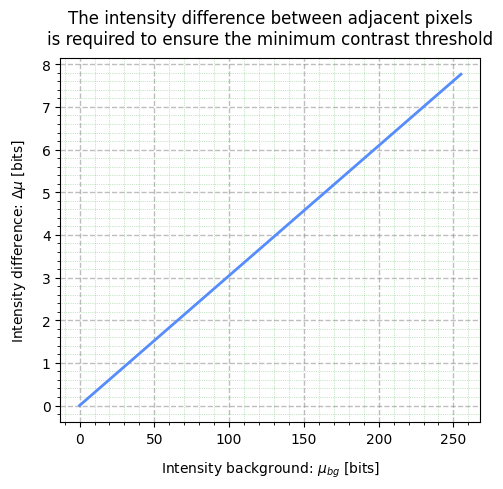

In [38]:
import matplotlib.pyplot as plt

_, axes = plt.subplots(figsize=(5, 5))
ax = axes

ax.plot(mu_bg, delta_mu, linewidth=2.0)

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title(f"The intensity difference between adjacent pixels\nis required to ensure the minimum contrast threshold", pad=10, loc='center', color='black')
ax.set_xlabel(f"Intensity background: $\\mu_{{bg}}$ [bits]", labelpad=10, loc='center', color='black')
ax.set_ylabel(f"Intensity difference: $\\Delta \\mu$ [bits]", labelpad=10, loc='center', color='black')

plt.tight_layout()
plt.show()

In [2]:
import apps.reporter as rpt

b = 2897.77

rp = rpt.Reporter()
rp.tolerance = 3

# average wavelength of the colors in micrometers
lambda_b = ((450 + 485) / 2) / 1000.0
lambda_g = ((500 + 565) / 2) / 1000.0
lambda_r = ((625 + 750) / 2) / 1000.0

rp.add_item("🟦 blue: λ", f"{rp.format_value(lambda_b)} μm")
rp.add_item("🟩 green: λ", f"{rp.format_value(lambda_g)} μm")
rp.add_item("🟥 red: λ", f"{rp.format_value(lambda_r)} μm")

# temperatures of these colors in Kelvins
T_b = b / lambda_b
T_g = b / lambda_g
T_r = b / lambda_r

rp.add_item("🟦 blue: T", f"{rp.format_value(T_b)} ºK")
rp.add_item("🟩 green: T", f"{rp.format_value(T_g)} ºK")
rp.add_item("🟥 red: T", f"{rp.format_value(T_r)} ºK")

# Print results
rp.print_pd_report("Color wavelength and temperature")

Attribute,Result
🟦 blue: λ,0.468 μm
🟩 green: λ,0.532 μm
🟥 red: λ,0.688 μm
🟦 blue: T,6198.439 ºK
🟩 green: T,5441.822 ºK
🟥 red: T,4214.938 ºK


In [3]:
import numpy as np


def planck_law(wavelength: np.ndarray | float, temperature: np.ndarray | float) -> np.ndarray | float:
    """
    Calculation spectral radiant emittance
    :param wavelength: wavelength in micrometers
    :param temperature: temperature in Kelvins
    :return: spectral radiant emittance
    """
    c_1 = 37415.0
    c_2 = 14388.0
    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        sre = c_1 / ((wavelength ** 5.0) * (np.exp(c_2 / (wavelength * temperature)) - 1.0))

    sre = np.nan_to_num(sre, nan=0.0, posinf=0.0)

    if isinstance(sre, np.ndarray) and sre.ndim == 0:
        return float(sre)

    return sre


In [4]:
import numpy as np

n_points = 1000
# lambda_min = 0.0
# lambda_max = 3.0
lambda_min = 0.38
lambda_max = 0.75

wavelengths_mkm = np.linspace(lambda_min, lambda_max, n_points)

# calculate data for charts
M_b = planck_law(wavelengths_mkm, T_b)
M_g = planck_law(wavelengths_mkm, T_g)
M_r = planck_law(wavelengths_mkm, T_r)


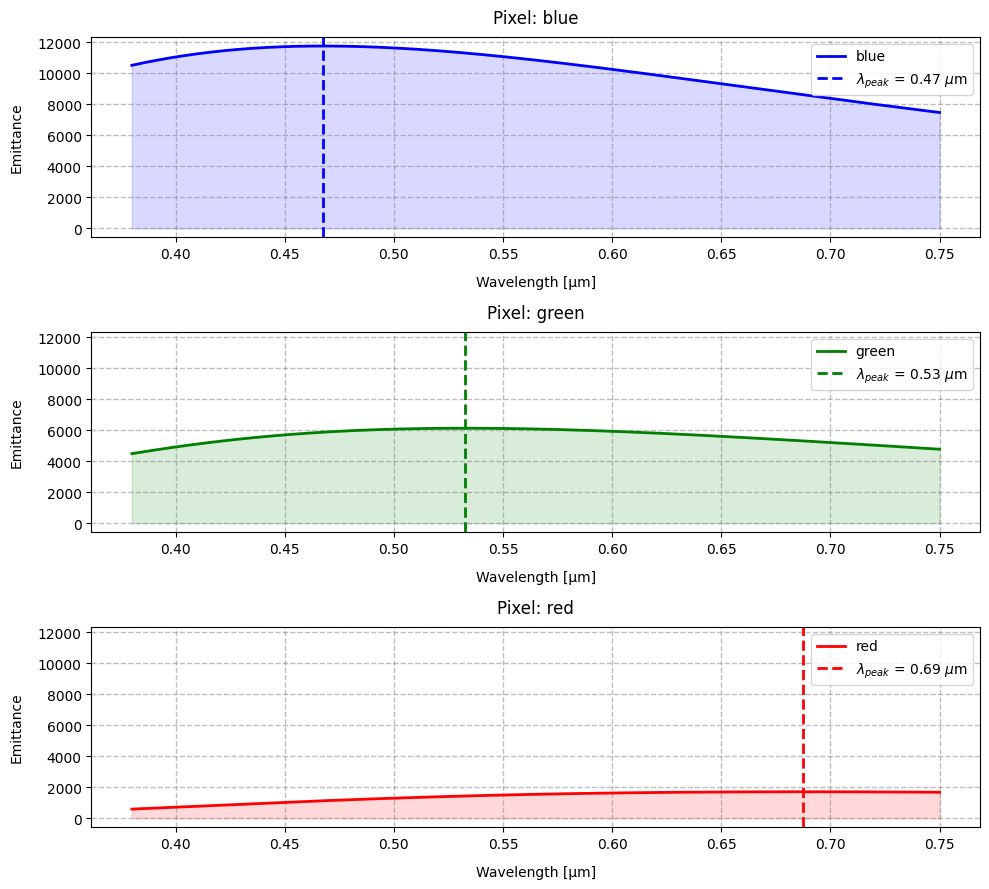

In [5]:
import matplotlib.pyplot as plt

M_array = [M_b, M_g, M_r]
lambda_peaks = [lambda_b, lambda_g, lambda_r]
color_names = ["blue", "green", "red"]

_, axes = plt.subplots(len(M_array), 1, figsize=(10, 9), sharey=True)

for idx, item in enumerate(M_array):
    ax = axes[idx]

    ax.plot(wavelengths_mkm, M_array[idx], linewidth=2.0, color=color_names[idx], label=color_names[idx])
    ax.fill_between(wavelengths_mkm, M_array[idx], alpha=0.15, color=color_names[idx])
    ax.axvline(lambda_peaks[idx], linestyle='--', color=color_names[idx], linewidth=2.0,
               label=f"$\\lambda _{{peak}}$ = {lambda_peaks[idx]:.2f} $\\mu$m")

    ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
    # ax.minorticks_on()
    ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
    ax.set_title(f"Pixel: {color_names[idx]}", pad=10, loc='center', color='black')
    ax.set_xlabel("Wavelength [μm]", labelpad=10, loc='center', color='black')
    ax.set_ylabel("Emittance", labelpad=10, loc='center', color='black')
    ax.legend()

plt.tight_layout()
plt.show()

## Eye sensitivity

Sources:
* [Colour Matching Functions Spectral Power Distributions](https://www.colour-science.org/api/0.3.4/html/colour.colorimetry.dataset.cmfs.html)
* [CVRL Database](http://www.cvrl.org/ciexyzpr.htm)
* [Coefficients for 2-deg colour](http://www.cvrl.org/database/text/cienewxyz/cie2012xyz2.htm)
* [Coefficients for 10-deg colour](http://www.cvrl.org/database/text/cienewxyz/cie2012xyz10.htm)



In [6]:
import numpy as np
import colour

use_2_degrees = True

colour_dataset_name = ("Stockman & Sharpe 2 Degree Cone Fundamentals"
                       if use_2_degrees
                       else "Stockman & Sharpe 10 Degree Cone Fundamentals")
k_L = (1.94735469 if use_2_degrees else 1.93986443)
k_M = (1.41445123 if use_2_degrees else 1.34664359)
k_S = (0.36476327 if use_2_degrees else 0.43044935)

# testing
# k_L, k_M, k_S = 1.0, 1.0, 1.0

# normalization
k_L, k_M, k_S = np.asanyarray([k_L, k_M, k_S]) / k_L

# Extract data on eye sensitivity
cmfs = colour.MSDS_CMFS[colour_dataset_name].copy()
wavelengths_nm = wavelengths_mkm * 1000.0

L_signal = cmfs.signals["l_bar"]
M_signal = cmfs.signals["m_bar"]
S_signal = cmfs.signals["s_bar"]

L_bar = L_signal.extrapolator(
    L_signal.interpolator(L_signal.wavelengths, L_signal.values),
    method="Constant", left=0, right=0)(wavelengths_nm) * k_L
M_bar = M_signal.extrapolator(
    M_signal.interpolator(M_signal.wavelengths, M_signal.values),
    method="Constant", left=0, right=0)(wavelengths_nm) * k_M
S_bar = S_signal.extrapolator(
    S_signal.interpolator(S_signal.wavelengths, S_signal.values),
    method="Constant", left=0, right=0)(wavelengths_nm) * k_S

SML_bar = L_bar + M_bar + S_bar

if np.max(SML_bar).astype(float) > 1.0:
    SML_bar /= np.max(SML_bar)

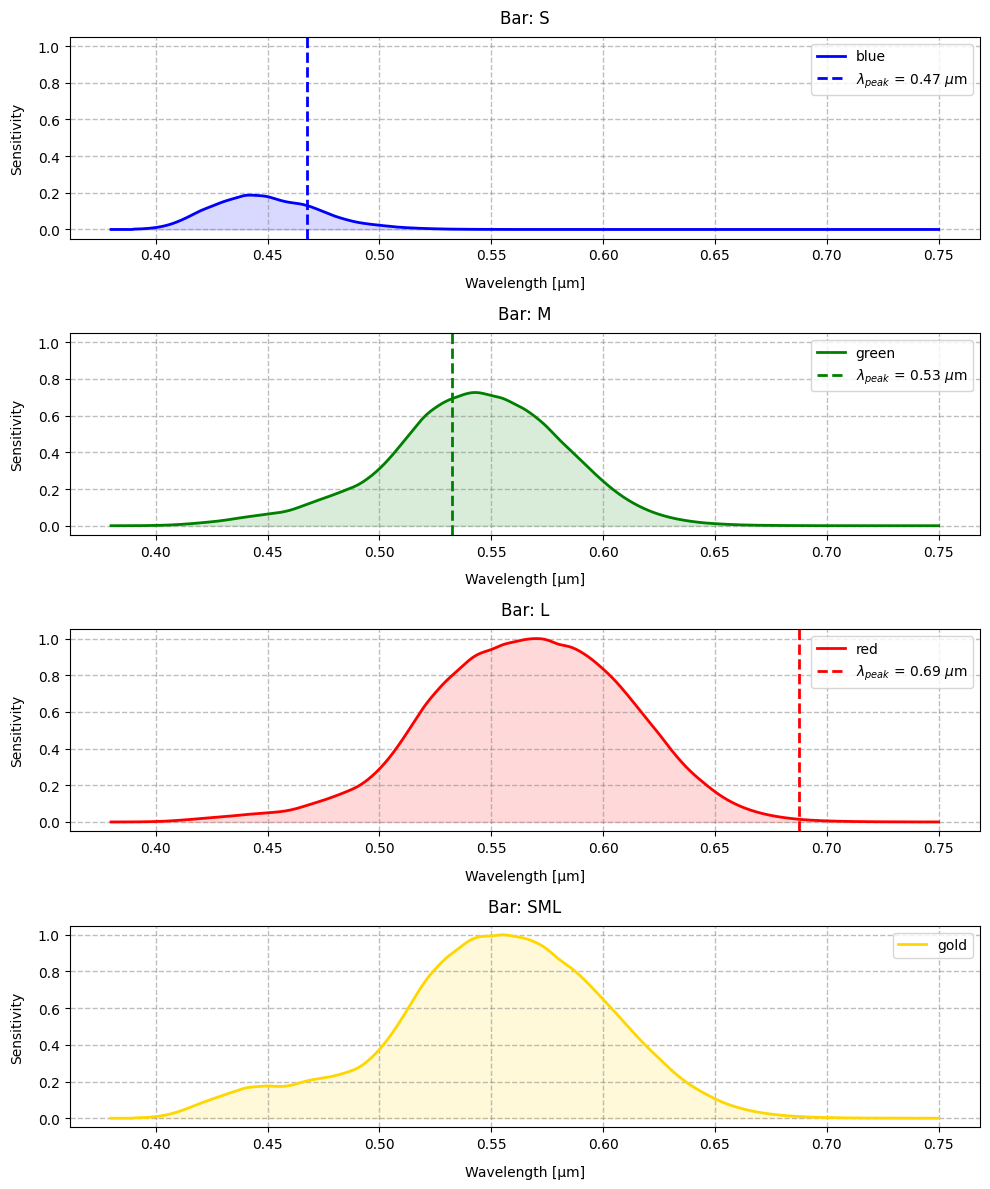

In [7]:
import matplotlib.pyplot as plt

color_names = ["blue", "green", "red", "gold"]
SML_array = [S_bar, M_bar, L_bar, SML_bar]
lambda_peaks = [lambda_b, lambda_g, lambda_r, 0]
bars = ['S', 'M', 'L', "SML"]

_, axes = plt.subplots(len(SML_array), 1, figsize=(10, 3 * len(SML_array)), sharey=True)

for idx, item in enumerate(SML_array):
    ax = axes[idx]

    ax.plot(wavelengths_mkm, SML_array[idx], linewidth=2.0, color=color_names[idx], label=color_names[idx])
    ax.fill_between(wavelengths_mkm, SML_array[idx], alpha=0.15, color=color_names[idx])
    if lambda_peaks[idx] != 0:
        ax.axvline(lambda_peaks[idx], linestyle='--', color=color_names[idx], linewidth=2.0,
                   label=f"$\\lambda _{{peak}}$ = {lambda_peaks[idx]:.2f} $\\mu$m")

    ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
    # ax.minorticks_on()
    ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
    ax.set_title(f"Bar: {bars[idx]}", pad=10, loc='center', color='black')
    ax.set_xlabel("Wavelength [μm]", labelpad=10, loc='center', color='black')
    ax.set_ylabel("Sensitivity", labelpad=10, loc='center', color='black')
    ax.legend()

plt.tight_layout()
plt.show()

## The luminous flux that enters the eye

Source: [PhD dissertation: f. (4.73), p. 170](https://rada.kpi.ua/files/dissertation/dis_Pinchuk%20B.Yu.pdf)

The spectral radiant flux incident on the eye (or on the sensor):
$$
 \Phi \left ( \lambda  \right ) = \mu \cdot \tau \cdot \frac{M_{T}\left ( \lambda \right ) A_{1} A_{2}}{\pi L_{ab}^{2}} \cdot cos\left ( \alpha \right )
$$
where:
$\alpha \approx 0^{\circ}$ – gaze angle relative to the screen normal, $\tau \approx 1 $ – transmittance of the optical system, $\mu$ – emissivity of a gray body, $A_{1}$ – emitting area of the screen in $cm^{2}$, $A_{2}$ – active area of the detector or image area in the focal plane (of the eye) in $cm^{2}$, $L_{ab}$ – source-to-detector distance in $cm$, $M_{T}$ – the spectral radiant emittance of an object at a given temperature T.

We can simplify the formula to the following form:
$$
 \Phi \left ( \lambda , \mu  \right ) \approx \mu \cdot \frac{M_{T}\left ( \lambda \right ) A_{1} A_{2}}{\pi L_{ab}^{2}}
$$

Source: [PhD dissertation: f. (4.72), p. 170](https://rada.kpi.ua/files/dissertation/dis_Pinchuk%20B.Yu.pdf)
The solid angle within which radiation from the object enters the entrance pupil:
$$
 \Omega = \frac{A_{1}}{L_{ab}^{2}} = \frac{A_{2}}{f_{eye}^{2}}
$$
where:
$f_{eye}$ – the focal length of the eye.

We have:
$$
 A_{2}=\frac{A_{1}\cdot f_{eye}^{2}}{L_{ab}^2}
$$

Source: [Focal Length of a Human Eye](https://hypertextbook.com/facts/2002/JuliaKhutoretskaya.shtml)
$$
f_{eye} = 1.7 cm
$$

Source: [Viewing the computer](https://www.aoa.org/healthy-eyes/eye-and-vision-conditions/computer-vision-syndrome)
$$
L_{ab} = 50 cm
$$


In [8]:
import numpy as np

max_bit = 255
A_1 = 10.0
L_ab = 50
# 17 - 24 mm
f_eye = 1.7

# Image area in the focal plane of the eye
A_2 = A_1 * ((f_eye / L_ab) ** 2)

# RGB colors for analysis
colors_dict = {
    "color_rgb_1": (100, 200, 100),
    "color_rgb_2": (150, 250, 150),
    "color_rgb_3": (100, 80, 100),
}

# color array
colors_rgb = list(colors_dict.values())
color_names = list(colors_dict.keys())

# emittance array
M_rgb = [M_r, M_g, M_b]
# emittance of each color
F_colors = []

for idx, item in enumerate(colors_rgb):
    mu = (np.asanyarray(item) / max_bit).reshape(3, 1)
    M_t = np.sum(M_rgb * mu, axis=0)
    F_t = (M_t * A_1 * A_2) / (np.pi * (L_ab ** 2))
    # save total emittance for color
    F_colors.append(F_t)


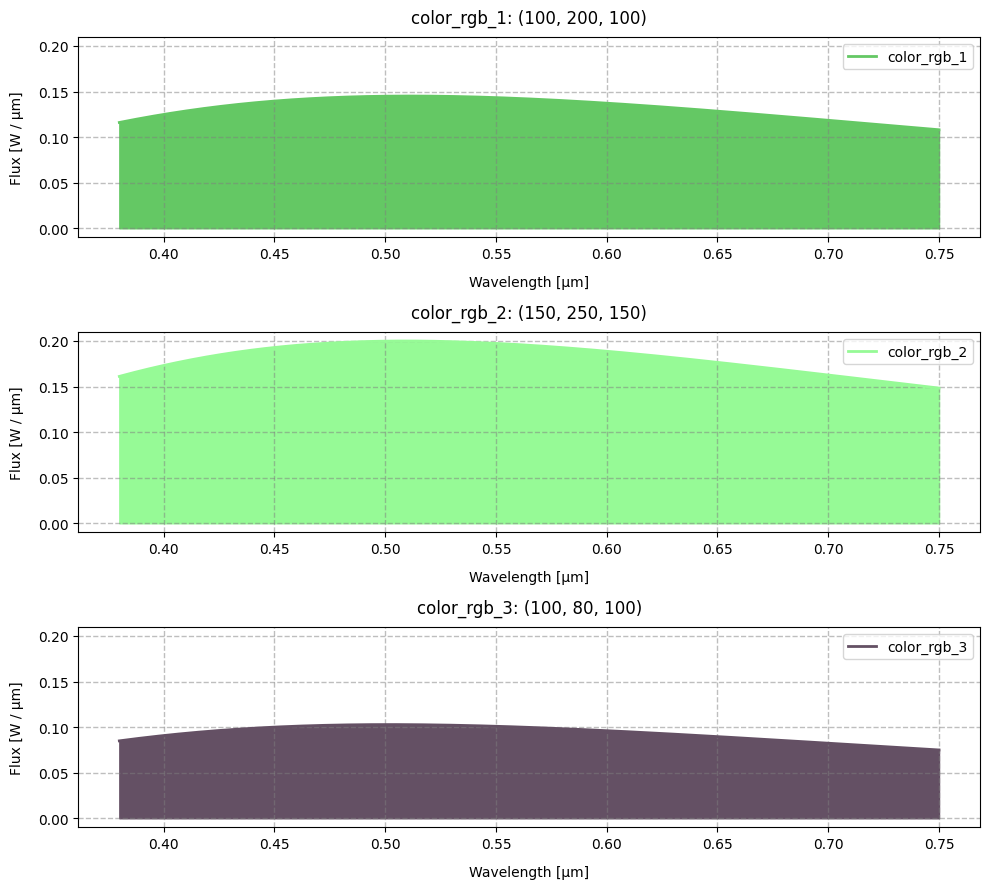

In [9]:
import matplotlib.pyplot as plt

M_array = F_colors

_, axes = plt.subplots(len(M_array), 1, figsize=(10, 3 * len(M_array)), sharey=True)

for idx, item in enumerate(M_array):
    ax = axes[idx]

    temp_color = np.asanyarray(colors_rgb[idx]) / max_bit
    ax.plot(wavelengths_mkm, M_array[idx], linewidth=2.0, color=temp_color, label=color_names[idx])
    ax.fill_between(wavelengths_mkm, M_array[idx], alpha=1.0, color=temp_color)

    ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
    # ax.minorticks_on()
    ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
    ax.set_title(f"{color_names[idx]}: {colors_rgb[idx]}", pad=10, loc='center', color='black')
    ax.set_xlabel("Wavelength [μm]", labelpad=10, loc='center', color='black')
    ax.set_ylabel("Flux [W / μm]", labelpad=10, loc='center', color='black')
    ax.legend()

plt.tight_layout()
plt.show()

## Color perception and correlation

In [10]:
import numpy as np
import pandas as pd
from IPython.display import display

# perception of each color
P_colors = F_colors * SML_bar

# create the data frame
df = pd.DataFrame(P_colors.T, columns=color_names)

# Pearson correlation
pearson_matrix = df.corr(method='pearson')
inverse_pm = 1.0 - pearson_matrix
# normalized inverse Pearson correlation matrix
normalized_pm = inverse_pm / np.max(np.abs(inverse_pm))

# Spearman correlation
spearman_matrix = df.corr(method='spearman')
inverse_sm = 1.0 - spearman_matrix
# normalized inverse Spearman correlation matrix
normalized_sm = inverse_sm / np.max(np.abs(inverse_sm))

display(df)
display(normalized_pm.style.set_caption("Normalized inverse Pearson correlation matrix"))
display(normalized_sm.style.set_caption("Normalized inverse Spearman correlation matrix"))

,color_rgb_1,color_rgb_2,color_rgb_3
0,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000
...,...,...,...
995,0.000012,0.000016,0.000008
996,0.000011,0.000016,0.000008
997,0.000011,0.000015,0.000008
998,0.000011,0.000015,0.000008


,color_rgb_1,color_rgb_2,color_rgb_3
color_rgb_1,0.000000,0.045331,1.000000
color_rgb_2,0.045331,0.000000,0.619510
color_rgb_3,1.000000,0.619510,0.000000


,color_rgb_1,color_rgb_2,color_rgb_3
color_rgb_1,0.000000,0.079878,1.000000
color_rgb_2,0.079878,0.000000,0.674378
color_rgb_3,1.000000,0.674378,0.000000


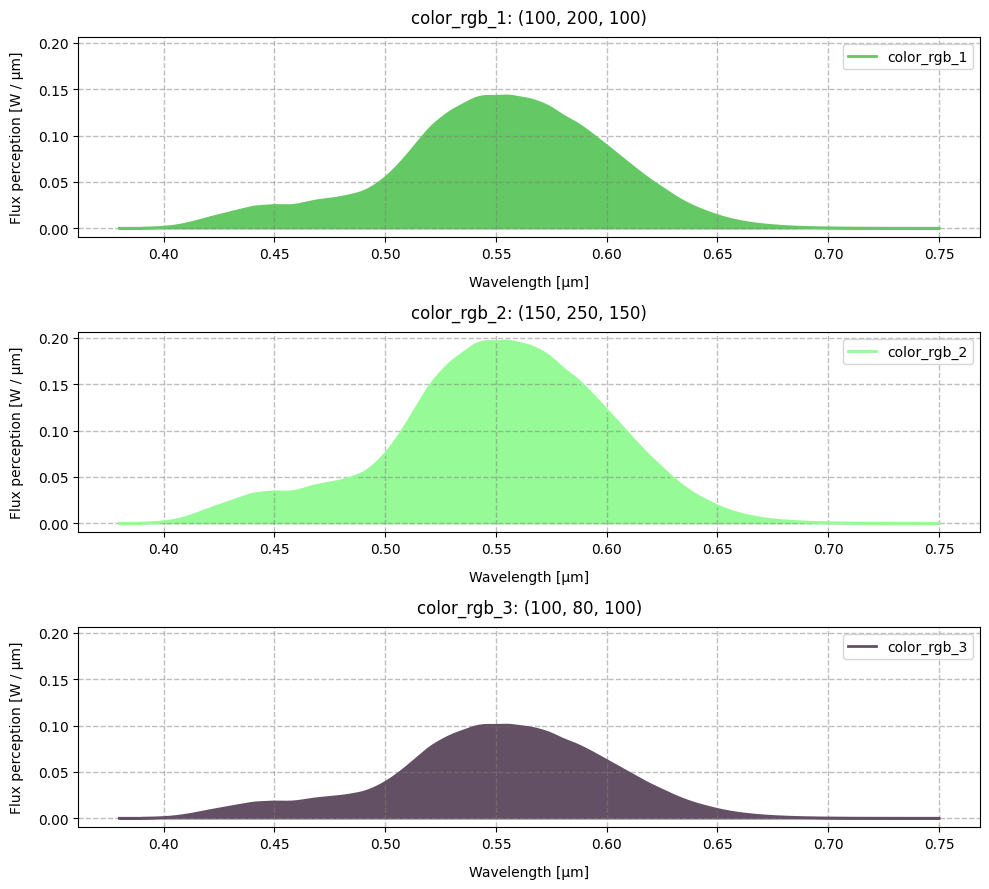

In [11]:
import matplotlib.pyplot as plt

M_array = P_colors
colors = color_names

_, axes = plt.subplots(len(M_array), 1, figsize=(10, 3 * len(M_array)), sharey=True)

for idx, item in enumerate(M_array):
    ax = axes[idx]

    temp_color = np.asanyarray(colors_rgb[idx]) / max_bit
    ax.plot(wavelengths_mkm, M_array[idx], linewidth=2.0, color=temp_color, label=colors[idx])
    ax.fill_between(wavelengths_mkm, M_array[idx], alpha=1.0, color=temp_color)

    ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
    # ax.minorticks_on()
    ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
    ax.set_title(f"{color_names[idx]}: {colors_rgb[idx]}", pad=10, loc='center', color='black')
    ax.set_xlabel("Wavelength [μm]", labelpad=10, loc='center', color='black')
    ax.set_ylabel("Flux perception [W / μm]", labelpad=10, loc='center', color='black')
    ax.legend()

plt.tight_layout()
plt.show()

## Conclusion

Using this physical and mathematical model, it can be seen that larger values in the normalized inverse matrices correspond to greater perceptual differences between the colors. Additionally, it is worth noting the primary advantage of correlation: its invariance to signal amplitude, which enabled us to achieve these results.
From the results, it can be seen that the colors color_rgb_1 and color_rgb_2 are closer to each other than either of them is to color_rgb_3. Thus, we have achieved the required result, which aligns closely with human perception.

Note: This model is not fully precise; to accelerate computations and demonstrate the core concept, certain parameters have been omitted or simplified.